In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [6]:
df = pd.read_csv("Bitcoin3.csv")
df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [7]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(53150, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB
None
Date           0
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64


In [8]:
features = ['Open', 'High', 'Low', 'Volume', 'Close']

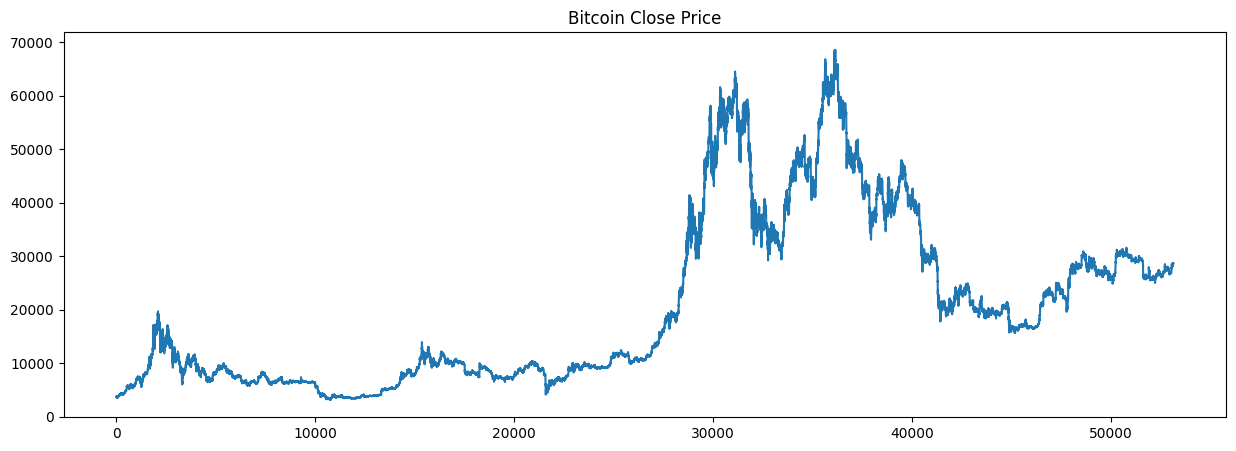

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title("Bitcoin Close Price")
plt.show()

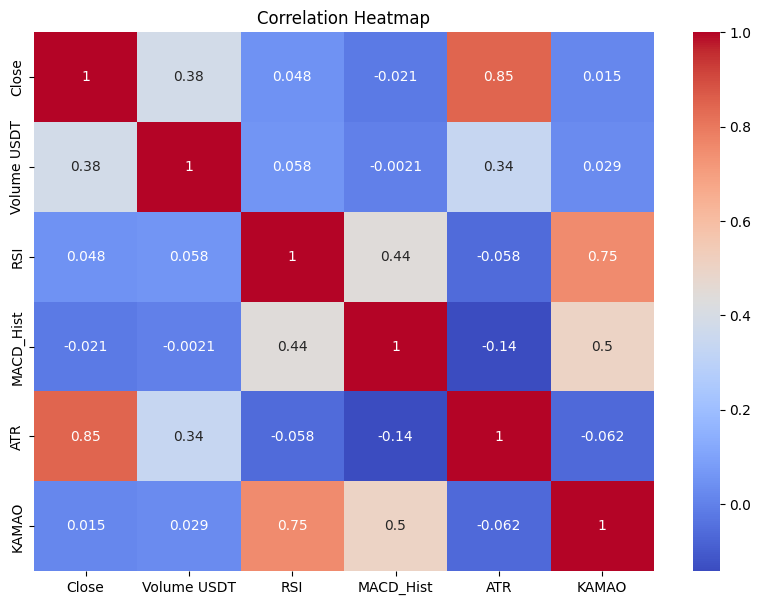

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'Close',
    'Volume USDT',
    'RSI',
    'MACD_Hist',
    'ATR',
    'KAMAO'
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

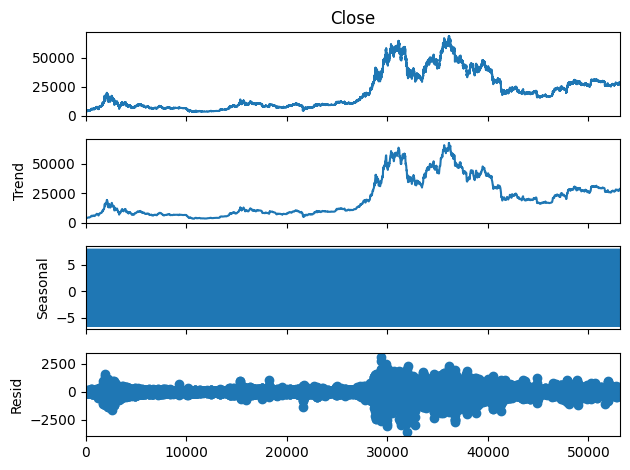

In [11]:
result = seasonal_decompose(df['Close'], model='additive', period=24)

result.plot()
plt.show()

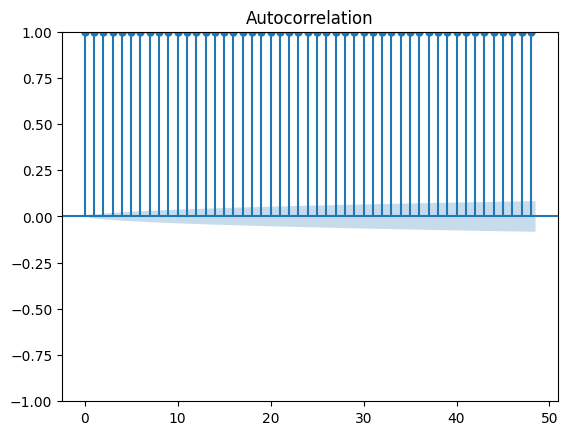

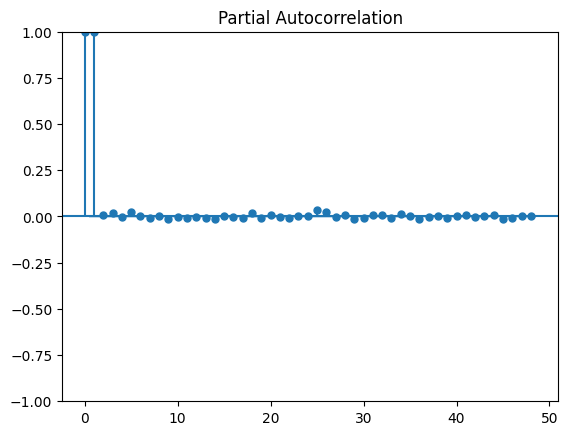

In [12]:
plot_acf(df['Close'], lags=48)
plt.show()

plot_pacf(df['Close'], lags=48)
plt.show()

In [13]:
df['Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df.dropna(inplace=True)

In [14]:
features.append('Rolling_Mean_24')

In [15]:
train_size = int(len(df)*0.7)
val_size = int(len(df)*0.15)

train_df = df[:train_size]
val_df = df[train_size:train_size+val_size]
test_df = df[train_size+val_size:]

In [16]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[features])

val_scaled = scaler.transform(val_df[features])

test_scaled = scaler.transform(test_df[features])

In [17]:
def create_dataset(data, window_size=48, horizon=24):
    X, y = [], []

    for i in range(len(data)-window_size-horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, -1])

    return np.array(X), np.array(y)

In [18]:
X_train, y_train = create_dataset(train_scaled)
X_val, y_val = create_dataset(val_scaled)
X_test, y_test = create_dataset(test_scaled)

In [19]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE)

In [20]:
class CustomDense(layers.Layer):

    def __init__(self, units):
        super(CustomDense, self).__init__()
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

In [22]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

WINDOW_SIZE = 48
HORIZON = 24

inputs = layers.Input(
    shape=(WINDOW_SIZE, len(features))
)

x = layers.LSTM(
    128,
    return_sequences=True
)(inputs)

x = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x, x)

x = layers.LSTM(64)(x)

outputs = CustomDense(HORIZON)(x)

baseline_model = Model(
    inputs,
    outputs
)

baseline_model.summary()

# =========================
# COMPILE BASELINE MODEL
# =========================

baseline_model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

# =========================
# TRAIN BASELINE MODEL
# =========================

history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 128)   │     69,632 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 128)   │     66,048 │ lstm_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 24)        │      1,560 │ lstm_3[0][0]      │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 186,648 (729.09 KB)

 Trainable params: 186,648 (729.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 179s 149ms/step - loss: 0.0285 - mae: 0.0285 - val_loss: 0.3276 - val_mae: 0.3276
Epoch 2/3
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 171s 148ms/step - loss: 0.0479 - mae: 0.0479 - val_loss: 0.3551 - val_mae: 0.3551
Epoch 3/3
1160/1160 ━━━━━━━━━━━━━━━━━━━━ 201s 147ms/step - loss: 0.0541 - mae: 0.0541 - val_loss: 0.3610 - val_mae: 0.3610


In [23]:
class CustomDense(layers.Layer):

    def __init__(self, units):
        super(CustomDense, self).__init__()
        self.units = units

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True,
            name='kernel'
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )

    def call(self, inputs):

        return tf.matmul(inputs, self.w) + self.b

    def compute_output_shape(self, input_shape):

        return input_shape[:-1] + (self.units,)

In [24]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# ======================================
# ENCODER
# ======================================

encoder_inputs = layers.Input(
    shape=(WINDOW_SIZE, len(features)),
    name="encoder_inputs"
)

encoder_lstm = layers.LSTM(
    128,
    return_state=True,
    name="encoder_lstm"
)

_, state_h, state_c = encoder_lstm(
    encoder_inputs
)

encoder_states = [state_h, state_c]

# ======================================
# DECODER INPUT (TEACHER FORCING)
# ======================================

decoder_inputs = layers.Input(
    shape=(HORIZON, len(features)),
    name="decoder_inputs"
)

# ======================================
# DECODER
# ======================================

decoder_lstm = layers.LSTM(
    128,
    return_sequences=True,
    name="decoder_lstm"
)

decoder_outputs = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

# ======================================
# ATTENTION
# ======================================a`

attention = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    name="multihead_attention"
)

attention_outputs = attention(
    decoder_outputs,
    decoder_outputs
)

# ======================================
# OUTPUT LAYER
# ======================================

decoder_outputs = layers.TimeDistributed(
    CustomDense(1),
    name="time_distributed_output"
)(
    attention_outputs
)

decoder_outputs = layers.Reshape(
    (HORIZON,),
    name="forecast_output"
)(
    decoder_outputs
)

# ======================================
# FINAL MODEL
# ======================================

seq2seq_model = Model(
    inputs=[
        encoder_inputs,
        decoder_inputs
    ],
    outputs=decoder_outputs,
    name="Seq2Seq_Teacher_Forcing"
)

seq2seq_model.summary()

Model: "Seq2Seq_Teacher_Forcing"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 48, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 24, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     69,632 │ encoder_inputs[0… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 24, 128)   │     69,632 │ decoder_inputs[0… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multihead_attention │ (None, 24, 128)   │     66,048 │ decoder_lstm[0][… │
│ (MultiHeadAttentio… │                   │            │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_o… │ (None, 24, 1)     │        129 │ multihead_attent… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 24)        │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,441 (802.50 KB)

 Trainable params: 205,441 (802.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ======================================
# TEACHER FORCING DATA
# ======================================

close_idx = features.index("Close")

def create_decoder_input(y):

    decoder_input = np.zeros(
        (
            len(y),
            HORIZON,
            len(features)
        )
    )

    decoder_input[:, :, close_idx] = y

    return decoder_input


decoder_train_input = create_decoder_input(
    y_train
)

decoder_val_input = create_decoder_input(
    y_val
)

decoder_test_input = create_decoder_input(
    y_test
)

In [26]:
class CustomMAE(tf.keras.losses.Loss):

    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred))

In [27]:
class WeightedMAE(tf.keras.losses.Loss):

    def call(self, y_true, y_pred):

        weights = tf.range(
            1,
            HORIZON+1,
            dtype=tf.float32
        )

        error = tf.abs(y_true - y_pred)

        weighted_error = error * weights

        return tf.reduce_mean(weighted_error)

In [28]:
class CustomEarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience
        self.best_loss = np.inf
        self.wait = 0

    def check(self, current_loss):

        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.wait = 0
            return False

        else:
            self.wait += 1

            if self.wait >= self.patience:
                return True

            return False

In [29]:
optimizer = tf.keras.optimizers.Adam()

loss_fn = WeightedMAE()

train_loss_results = []
val_loss_results = []

In [30]:
# ======================================
# CUSTOM TRAIN STEP
# ======================================

def train_step(
    encoder_batch,
    decoder_batch,
    y_batch
):

    with tf.GradientTape() as tape:

        predictions = seq2seq_model(
            [
                encoder_batch,
                decoder_batch
            ],
            training=True
        )

        loss = loss_fn(
            y_batch,
            predictions
        )

    gradients = tape.gradient(
        loss,
        seq2seq_model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            seq2seq_model.trainable_variables
        )
    )

    return loss

In [31]:
class CustomEarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience
        self.best_loss = np.inf
        self.wait = 0

    def check(self, current_loss):

        if current_loss < self.best_loss:

            self.best_loss = current_loss
            self.wait = 0

            return False

        else:

            self.wait += 1

            if self.wait >= self.patience:

                return True

            return False

In [34]:
BATCH_SIZE = 64
EPOCHS = 3

early_stopper = CustomEarlyStopping(
    patience=5
)

for epoch in range(EPOCHS):

    train_losses = []

    for start in range(
        0,
        len(X_train),
        BATCH_SIZE
    ):

        end = start + BATCH_SIZE

        encoder_batch = X_train[start:end]

        decoder_batch = decoder_train_input[start:end]

        y_batch = y_train[start:end]

        loss = train_step(
            encoder_batch,
            decoder_batch,
            y_batch
        )

        train_losses.append(
            loss.numpy()
        )

    avg_train_loss = np.mean(
        train_losses
    )

    val_losses = []

    for start in range(
        0,
        len(X_val),
        BATCH_SIZE
    ):

        end = start + BATCH_SIZE

        val_predictions = seq2seq_model(
            [
                X_val[start:end],
                decoder_val_input[start:end]
            ],
            training=False
        )

        val_loss = loss_fn(
            y_val[start:end],
            val_predictions
        )

        val_losses.append(
            val_loss.numpy()
        )

    avg_val_loss = np.mean(
        val_losses
    )

    train_loss_results.append(
        avg_train_loss
    )

    val_loss_results.append(
        avg_val_loss
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    if early_stopper.check(
        avg_val_loss
    ):

        print(
            "Early stopping triggered"
        )

        break

Epoch 1/10 | Loss: 0.3156 | Val Loss: 2.7737
Epoch 2/10 | Loss: 0.4927 | Val Loss: 2.8092
Epoch 3/10 | Loss: 0.5232 | Val Loss: 1.9806
Epoch 4/10 | Loss: 0.5362 | Val Loss: 2.0436
Epoch 5/10 | Loss: 0.3905 | Val Loss: 1.9608
Epoch 6/10 | Loss: 0.4367 | Val Loss: 2.2736
Epoch 7/10 | Loss: 0.3220 | Val Loss: 1.4361
Epoch 8/10 | Loss: 0.2896 | Val Loss: 1.4407
Epoch 9/10 | Loss: 0.2287 | Val Loss: 1.2394
Epoch 10/10 | Loss: 0.2175 | Val Loss: 1.1475


In [35]:
baseline_predictions = baseline_model.predict(X_test)

247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step


In [36]:
baseline_mae = mean_absolute_error(
    y_test.flatten(),
    baseline_predictions.flatten()
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 0.4337416600927024


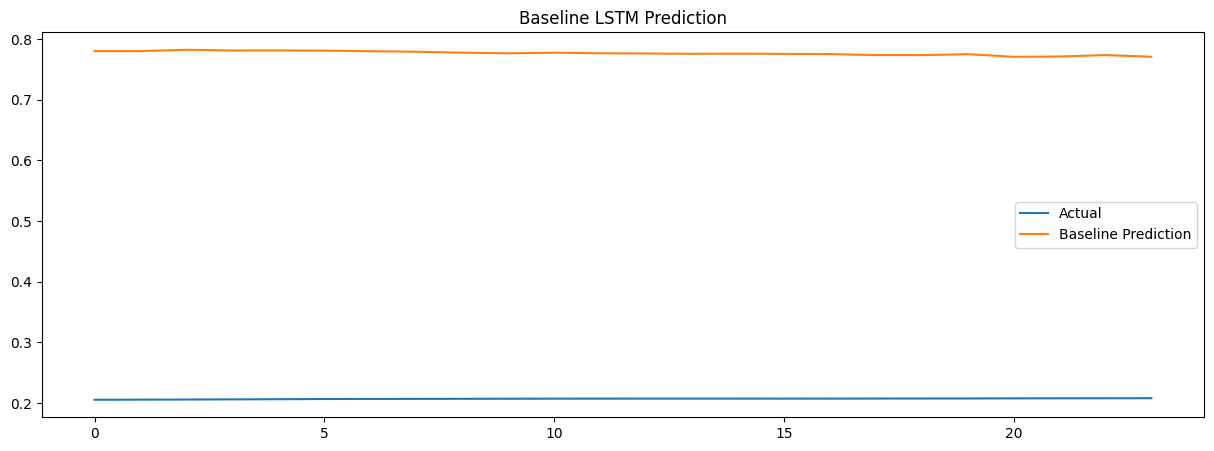

In [37]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test[0],
    label='Actual'
)

plt.plot(
    baseline_predictions[0],
    label='Baseline Prediction'
)

plt.title("Baseline LSTM Prediction")

plt.legend()

plt.show()

In [53]:
baseline_comparison = pd.DataFrame({
    'Actual': y_test[0],
    'Prediction': baseline_predictions[0]
})

baseline_comparison['Difference'] = abs(
    baseline_comparison['Actual']
    -
    baseline_comparison['Prediction']
)

baseline_comparison.head(24)

,Actual,Prediction,Difference
0,0.205548,0.780289,0.574741
1,0.205769,0.780322,0.574553
2,0.205981,0.782463,0.576482
3,0.206225,0.781302,0.575077
4,0.206472,0.781456,0.574984
5,0.206813,0.781060,0.574247
6,0.206931,0.780111,0.573180
7,0.207012,0.779273,0.572260
8,0.207135,0.777690,0.570555
9,0.207259,0.776636,0.569376


In [44]:
seq2seq_predictions = seq2seq_model.predict(
    [
        X_test,
        decoder_test_input
    ]
)

247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step


In [45]:
seq2seq_mae = mean_absolute_error(
    y_test.flatten(),
    seq2seq_predictions.flatten()
)

print("Seq2Seq MAE:", seq2seq_mae)

Seq2Seq MAE: 0.1279708974504764


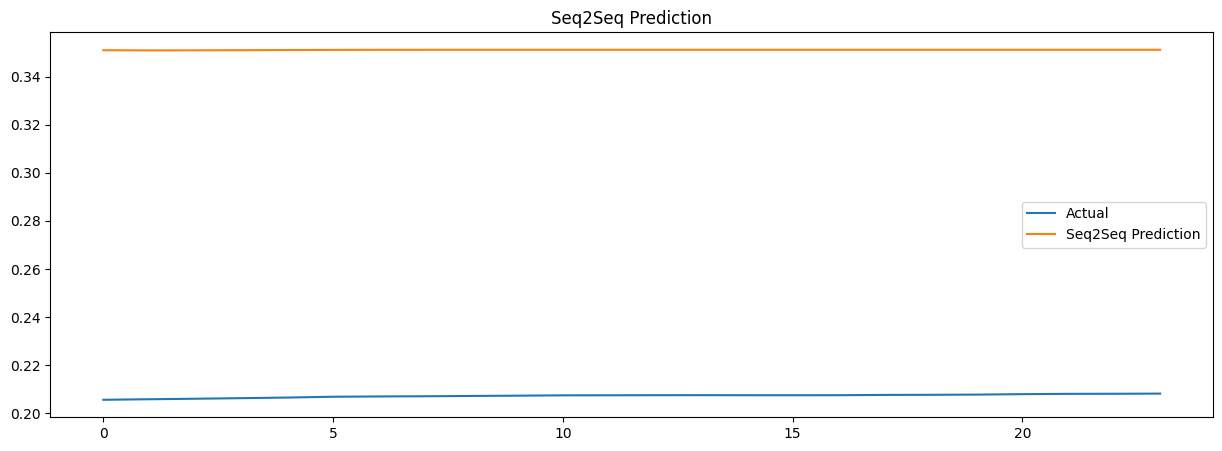

In [46]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test[0],
    label='Actual'
)

plt.plot(
    seq2seq_predictions[0],
    label='Seq2Seq Prediction'
)

plt.title("Seq2Seq Prediction")

plt.legend()

plt.show()

In [47]:
seq2seq_comparison = pd.DataFrame({
    'Actual': y_test[0],
    'Prediction': seq2seq_predictions[0]
})

seq2seq_comparison['Difference'] = abs(
    seq2seq_comparison['Actual']
    -
    seq2seq_comparison['Prediction']
)

seq2seq_comparison.head(24)

,Actual,Prediction,Difference
0,0.205548,0.351058,0.145509
1,0.205769,0.350988,0.145219
2,0.205981,0.351012,0.145031
3,0.206225,0.351075,0.144850
4,0.206472,0.351142,0.144671
5,0.206813,0.351194,0.144381
6,0.206931,0.351225,0.144294
7,0.207012,0.351239,0.144227
8,0.207135,0.351243,0.144108
9,0.207259,0.351243,0.143983


In [48]:
baseline_model.save(
    "model_baseline_LSTM.keras"
)

seq2seq_model.save(
    "model_seq2seq_LSTM.keras"
)

seq2seq_model.save(
    "best_model_seq2seq_LSTM.keras"
)